KMeans clustering results
Sample size: 5000
Number of clusters: 3
Silhouette score: 0.0247

Cluster composition summary
   cluster  num_sentences  p_rate  i_rate  o_rate  avg_labels_per_sentence
0        0           1494  0.2108  0.3159  0.3956                   0.9224
1        1           1723  0.1532  0.3964  0.6053                   1.1550
2        2           1783  0.2518  0.5536  0.3999                   1.2053

P label count by cluster
p_label     0    1
cluster           
0        1179  315
1        1459  264
2        1334  449

I label count by cluster
i_label     0    1
cluster           
0        1022  472
1        1040  683
2         796  987

O label count by cluster
o_label     0     1
cluster            
0         903   591
1         680  1043
2        1070   713

Example sentences per cluster

Cluster 0
- Pre-operative short-term pulmonary rehabilitation for patients of chronic obstructive pulmonary disease undergoing coronary artery bypass graft surgery .
  [P=0, I=1, O

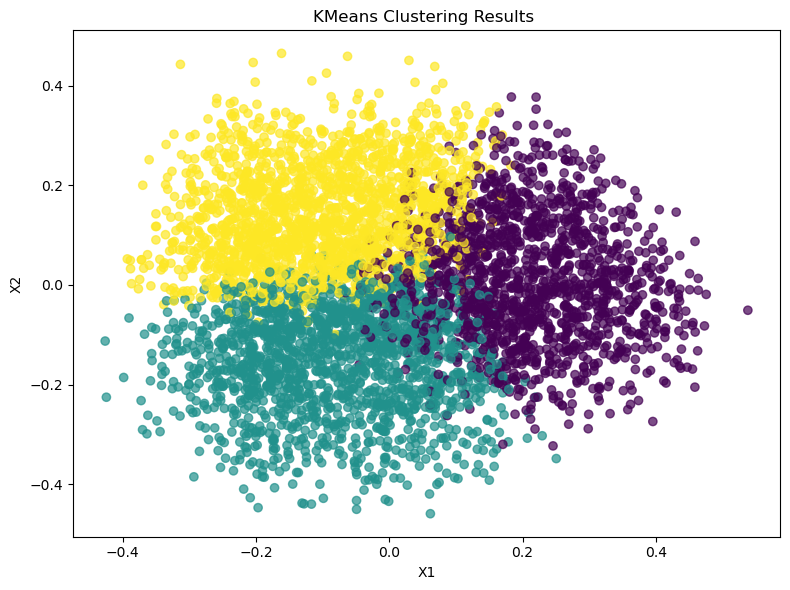

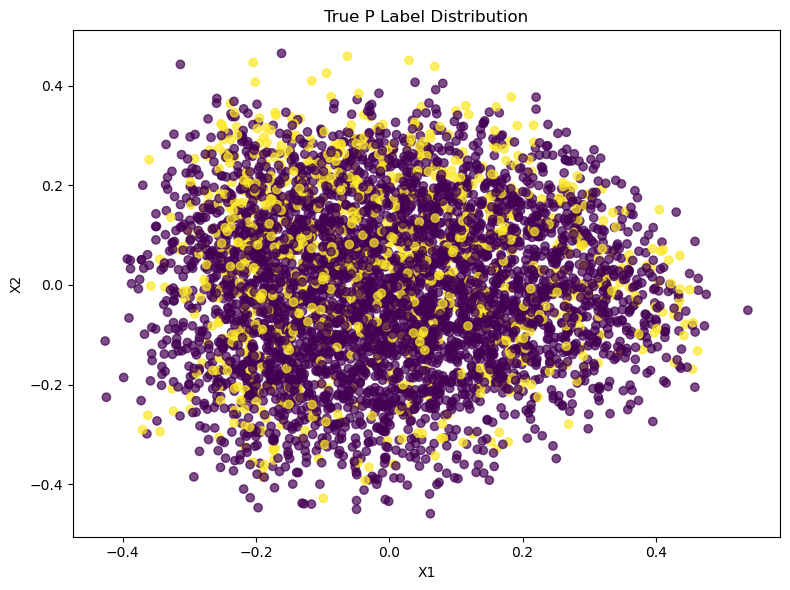

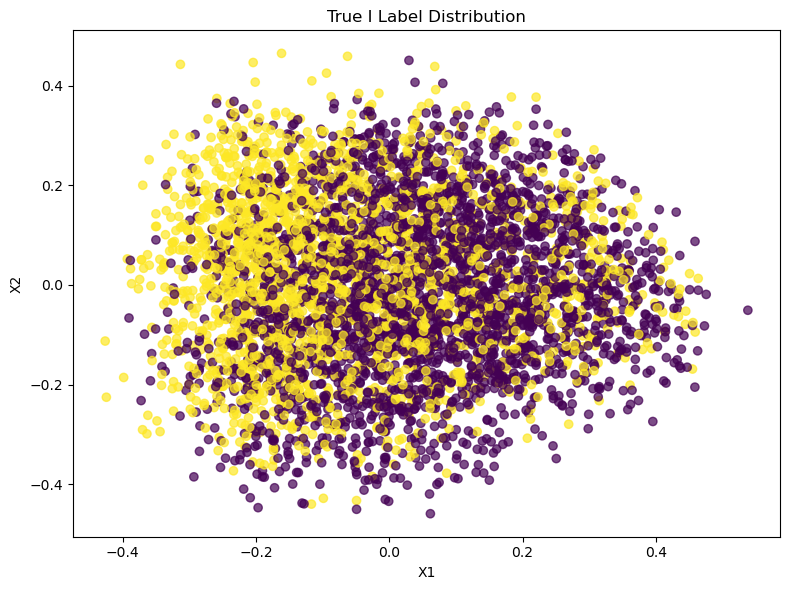

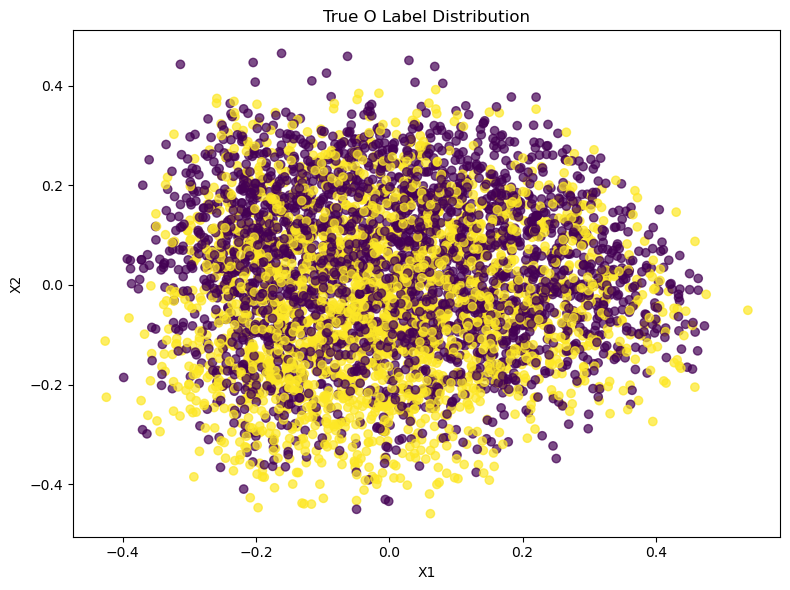

C:\Users\eik\AppData\Local\Temp\ipykernel_31404\3797094873.py:215: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


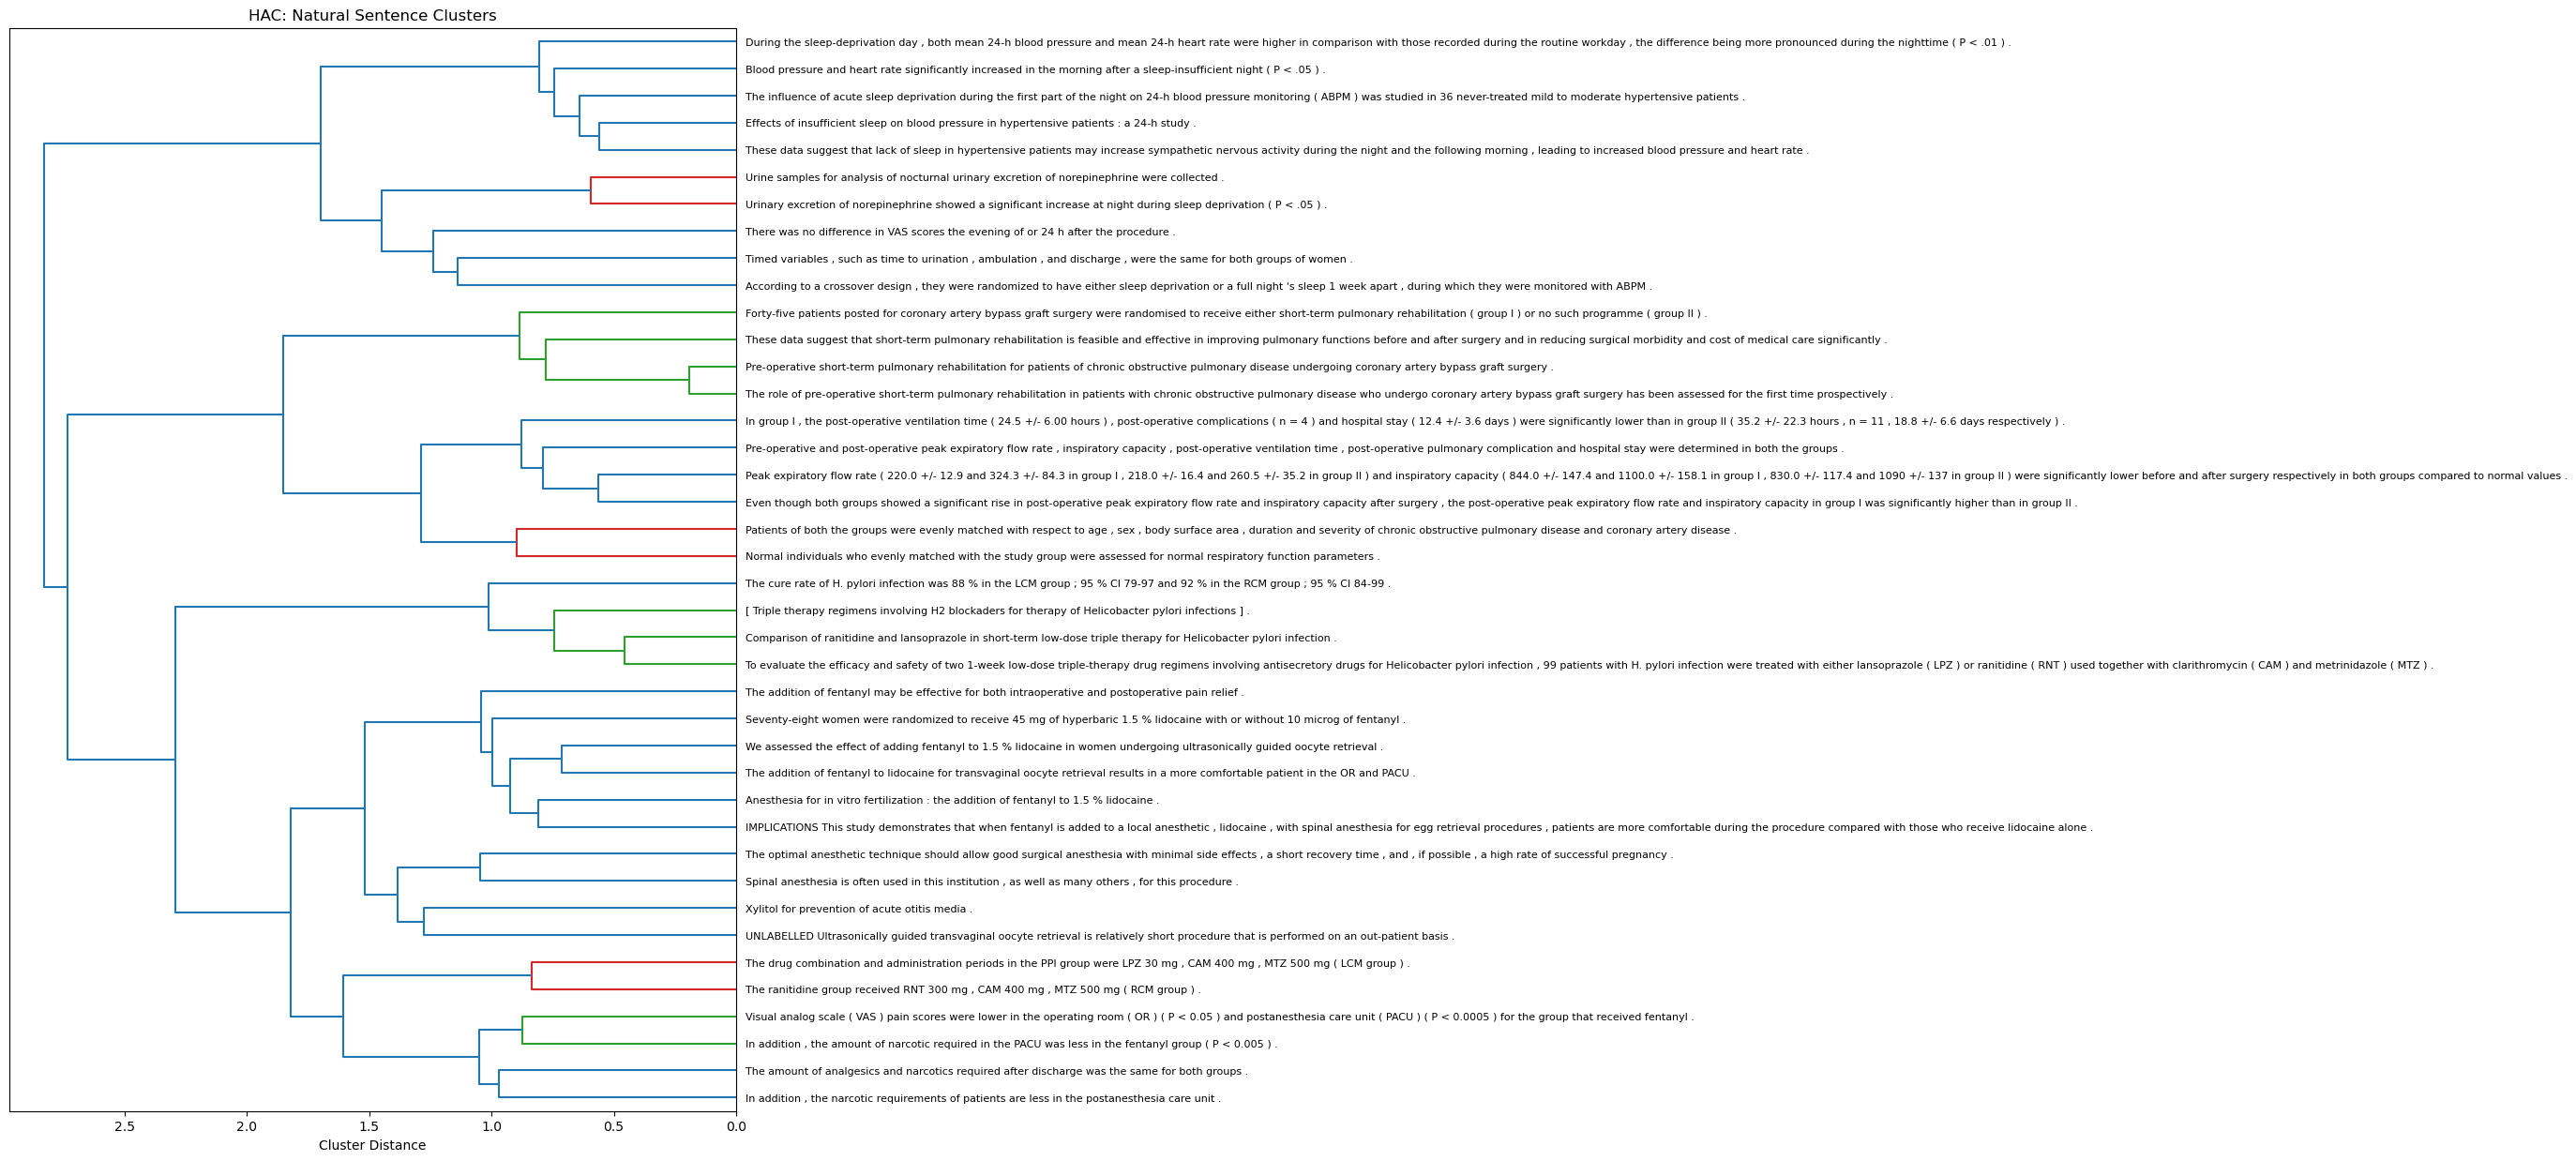

Unified prediction table saved to Y:\222\task1-cluster\cluster_kmeans_predictions.csv
Cluster-to-field mapping: {'Pop': 2, 'Int': 2, 'Out': 1}


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import set_link_color_palette


PROJECT_ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "data" / "ebm_nlp_2_00").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find data/ebm_nlp_2_00 from the current notebook directory")

DATA_FILE = PROJECT_ROOT / "ebm_nlp_2_00" / "processed" / "sentence_vectors.npz"
OUTPUT_DIR = PROJECT_ROOT / "task1-cluster"
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_CSV = OUTPUT_DIR / "cluster_kmeans_predictions.csv"
PREDICTION_COLUMNS = ["method", "doc_id", "text", "Pop_gold", "Pop_pred", "Int_gold", "Int_pred", "Out_gold", "Out_pred"]

data = np.load(DATA_FILE, allow_pickle=True)

X_train = data["X_train"]
train_texts = data["texts_train"]

y_p_train = data["y_p_train"]
y_i_train = data["y_i_train"]
y_o_train = data["y_o_train"]

X_test = data["X_test"]
test_texts = data["texts_test"]
y_p_test = data["y_p_test"]
y_i_test = data["y_i_test"]
y_o_test = data["y_o_test"]
test_doc_ids = data["test_doc_ids"] if "test_doc_ids" in data.files else np.array([f"test_sentence_{i}" for i in range(len(test_texts))], dtype=object)


def build_cluster_result_df(X, texts, y_p, y_i, y_o, cluster_ids):
    result_df = pd.DataFrame({
        "sentence": texts,
        "p_label": y_p,
        "i_label": y_i,
        "o_label": y_o,
        "cluster": cluster_ids
    })
    return result_df


def summarise_cluster_composition(result_df):
    summary_rows = []

    for cluster_id in sorted(result_df["cluster"].unique()):
        cluster_df = result_df[result_df["cluster"] == cluster_id]

        n_sent = len(cluster_df)
        p_rate = cluster_df["p_label"].mean()
        i_rate = cluster_df["i_label"].mean()
        o_rate = cluster_df["o_label"].mean()

        avg_labels_per_sentence = (
            cluster_df["p_label"] + cluster_df["i_label"] + cluster_df["o_label"]
        ).mean()

        summary_rows.append({
            "cluster": cluster_id,
            "num_sentences": n_sent,
            "p_rate": round(p_rate, 4),
            "i_rate": round(i_rate, 4),
            "o_rate": round(o_rate, 4),
            "avg_labels_per_sentence": round(avg_labels_per_sentence, 4)
        })

    summary_df = pd.DataFrame(summary_rows)
    return summary_df


def print_cluster_examples(result_df, n_examples=5):
    print("\nExample sentences per cluster")
    for cluster_id in sorted(result_df["cluster"].unique()):
        print(f"\nCluster {cluster_id}")
        cluster_examples = result_df[result_df["cluster"] == cluster_id].head(n_examples)

        for _, row in cluster_examples.iterrows():
            print(
                f'- {row["sentence"]}\n'
                f'  [P={row["p_label"]}, I={row["i_label"]}, O={row["o_label"]}]'
            )



def plot_kmeans_clusters(X_subset, cluster_ids, title_suffix=""):
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_subset)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=cluster_ids,
        alpha=0.7
    )
    plt.title(f"KMeans Clustering Results {title_suffix}")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.tight_layout()
    plt.show()



def plot_label_distribution(X_subset, y_subset, label_name="P"):
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_subset)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=y_subset,
        alpha=0.7
    )
    plt.title(f"True {label_name} Label Distribution")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.tight_layout()
    plt.show()


def analyse_kmeans_multilabel(
    n_clusters=3,
    sample_size=5000,
    random_state=42,
    plot=True,
    n_examples=5
):

    limit = min(sample_size, len(X_train))

    X_subset = X_train[:limit]
    text_subset = train_texts[:limit]
    y_p_subset = y_p_train[:limit]
    y_i_subset = y_i_train[:limit]
    y_o_subset = y_o_train[:limit]

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    cluster_ids = kmeans.fit_predict(X_subset)

    print("KMeans clustering results")
    print(f"Sample size: {limit}")
    print(f"Number of clusters: {n_clusters}")

    sil = silhouette_score(X_subset, cluster_ids)
    print(f"Silhouette score: {sil:.4f}")

    result_df = build_cluster_result_df(
        X_subset,
        text_subset,
        y_p_subset,
        y_i_subset,
        y_o_subset,
        cluster_ids
    )
   
    summary_df = summarise_cluster_composition(result_df)

    print("\nCluster composition summary")
    print(summary_df)

    print("\nP label count by cluster")
    print(pd.crosstab(result_df["cluster"], result_df["p_label"]))

    print("\nI label count by cluster")
    print(pd.crosstab(result_df["cluster"], result_df["i_label"]))

    print("\nO label count by cluster")
    print(pd.crosstab(result_df["cluster"], result_df["o_label"]))


    print_cluster_examples(result_df, n_examples=n_examples)

  
    if plot:
        plot_kmeans_clusters(X_subset, cluster_ids)
        plot_label_distribution(X_subset, y_p_subset, label_name="P")
        plot_label_distribution(X_subset, y_i_subset, label_name="I")
        plot_label_distribution(X_subset, y_o_subset, label_name="O")

    return result_df, summary_df



def plot_hac(sample_size=40):
    set_link_color_palette(["#1f77b4", "#2ca02c", "#d62728"])

    limit = min(sample_size, len(X_train))
    X_hac = X_train[:limit]
    labels_hac = train_texts[:limit]

    linked_sentences = linkage(X_hac, method="ward")

    plt.figure(figsize=(10, 15))
    dendrogram(
        linked_sentences,
        orientation="left",
        labels=labels_hac,
        distance_sort="descending",
        show_leaf_counts=True,
        leaf_font_size=8,
        color_threshold=1.0
    )

    plt.title("HAC: Natural Sentence Clusters")
    plt.xlabel("Cluster Distance")
    plt.tight_layout()
    plt.show()

    set_link_color_palette(None)


def sentence_or_null(text, label):
    return text if int(label) == 1 else "null"


def build_cluster_prediction_table(n_clusters=3, sample_size=5000, random_state=42):
    limit = min(sample_size, len(X_train))
    X_subset = X_train[:limit]
    y_subset = {
        "Pop": y_p_train[:limit],
        "Int": y_i_train[:limit],
        "Out": y_o_train[:limit],
    }

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    train_clusters = kmeans.fit_predict(X_subset)
    test_clusters = kmeans.predict(X_test)

    cluster_to_field = {}
    for field, labels in y_subset.items():
        rates = pd.Series(labels).groupby(train_clusters).mean()
        cluster_to_field[field] = int(rates.idxmax())

    sentence_rows = []
    for i, text in enumerate(test_texts):
        cluster_id = int(test_clusters[i])
        sentence_rows.append({
            "method": "cluster_kmeans",
            "doc_id": test_doc_ids[i],
            "text": text,
            "Pop_gold": sentence_or_null(text, y_p_test[i]),
            "Pop_pred": text if cluster_id == cluster_to_field["Pop"] else "null",
            "Int_gold": sentence_or_null(text, y_i_test[i]),
            "Int_pred": text if cluster_id == cluster_to_field["Int"] else "null",
            "Out_gold": sentence_or_null(text, y_o_test[i]),
            "Out_pred": text if cluster_id == cluster_to_field["Out"] else "null",
        })


    sentence_df = pd.DataFrame(sentence_rows)
    doc_rows = []
    for doc_id, group in sentence_df.groupby("doc_id", sort=False):
        row = {
            "method": "cluster_kmeans",
            "doc_id": doc_id,
            "text": " ".join(group["text"].astype(str)),
        }
        for field in ["Pop", "Int", "Out"]:
            for kind in ["gold", "pred"]:
                values = [v for v in group[f"{field}_{kind}"].astype(str) if v.lower() != "null"]
                row[f"{field}_{kind}"] = " ; ".join(values) if values else "null"
        doc_rows.append(row)

    prediction_df = pd.DataFrame(doc_rows).reindex(columns=PREDICTION_COLUMNS)
    prediction_df.to_csv(OUTPUT_CSV, index=False)
    print(f"Unified prediction table saved to {OUTPUT_CSV}")
    print("Cluster-to-field mapping:", cluster_to_field)
    return prediction_df, cluster_to_field


kmeans_results, cluster_summary = analyse_kmeans_multilabel(
    n_clusters=3,
    sample_size=5000,
    random_state=42,
    plot=True,
    n_examples=5
)

plot_hac(sample_size=40)

cluster_predictions, cluster_to_field = build_cluster_prediction_table(
    n_clusters=3,
    sample_size=5000,
    random_state=42
)